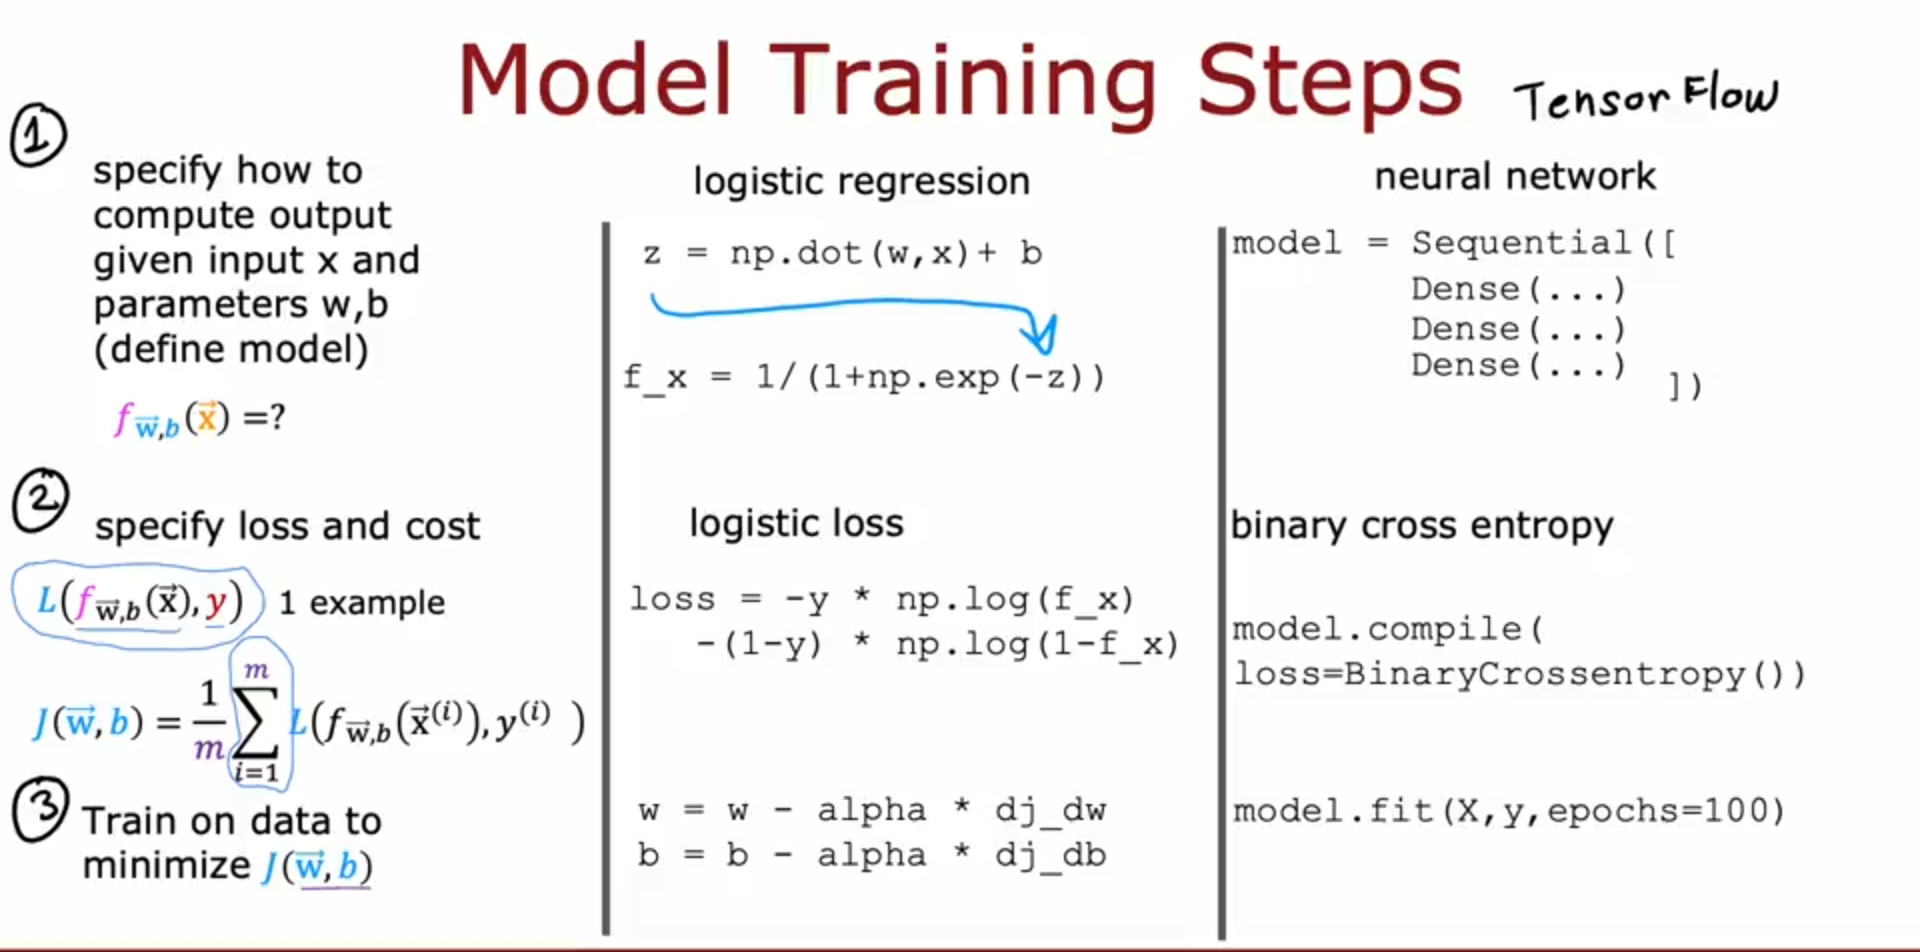

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Normalization
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam

# 1. ADIM: VERİ SETİ HAZIRLIĞI (Dummy Data)

# Otonom aracın kamerasından gelmiş gibi 1000 adet 400 piksellik görüntü (X)
X = np.random.rand(1000, 400)  

# Bu 1000 görüntünün cevapları (Y): 1 (Yaya var) veya 0 (Yaya yok)
Y = np.random.randint(0, 2, size=(1000, 1)) 



# 2. ADIM: NORMALİZASYON KATMANI (Sıfırıncı Adım)

# Normalizasyon katmanını oluşturuyoruz
norm_layer = Normalization(axis=-1)

# ÇOK KRİTİK: Katmana X verisini gösterip ortalama (mu) ve varyansı (sigma) hesaplatıyoruz
norm_layer.adapt(X) 



# 3. ADIM: MODEL MİMARİSİNİ KURMAK

model = Sequential([
    # En başa veriyi ezen (normalize eden) katmanımız
    norm_layer,
    
    # Karar veren öğrenci nöronlar (Gizli Katmanlar)
    Dense(units=25, activation='sigmoid'),
    Dense(units=15, activation='sigmoid'),
    
    # Çıktı Katmanı: 0 ile 1 arası bir olasılık verecek
    Dense(units=1, activation='sigmoid')
])



# 4. ADIM: CEZA SİSTEMİ VE OPTİMİZASYON (Compile)

model.compile(
    loss=BinaryCrossentropy(),        # Hatayı ölçeceğimiz log loss fonksiyonu
    optimizer=Adam(learning_rate=0.001) # Gradyan inişini yönetecek algoritma (Andrew Ng'nin favorilerinden)
)


# 5. ADIM: SİMÜLASYON VE EĞİTİM (Fit)
print("Model eğitimi başlıyor...")
# Verinin %20'sini test (validation) için ayırıp, modeli 10 tur (epoch) eğitiyoruz
history = model.fit(X, Y, epochs=10, validation_split=0.2)


# 6. ADIM: GERÇEK DÜNYA TAHMİNİ (Predict)
print("\nEğitim bitti, yeni bir görüntü için tahmin yapılıyor...")

# Kameradan yeni bir 400 piksellik ham veri geldiğini düşünelim
X_yeni = np.random.rand(1, 400)

# Model olasılığı hesaplıyor (ör: %85 ihtimal)
olasilik = model.predict(X_yeni)

# Olasılığı %50 eşik değeriyle karar ağacına (0 veya 1) çeviriyoruz
karar = 1 if olasilik >= 0.5 else 0

print(f"Modelin Çıkardığı Ham Olasılık: {olasilik[0][0]:.4f}")
print(f"Otonom Sistemin Kararı: {'Yaya Var (1) - FREN YAP!' if karar == 1 else 'Yol Boş (0) - DEVAM ET'}")

Model eğitimi başlıyor...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.7765 - val_loss: 0.7354
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7019 - val_loss: 0.6986
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6756 - val_loss: 0.6917
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6619 - val_loss: 0.6930
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6490 - val_loss: 0.6935
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6342 - val_loss: 0.6968
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6170 - val_loss: 0.7007
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5975 - val_loss: 0.7069
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5769 - val_loss: 0.7151
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5544 - val_loss: 0.7270

Eğitim bitti, yeni bir görüntü için tahmin yapılıyor...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
Modelin Çıkardığı Ham Olasılık

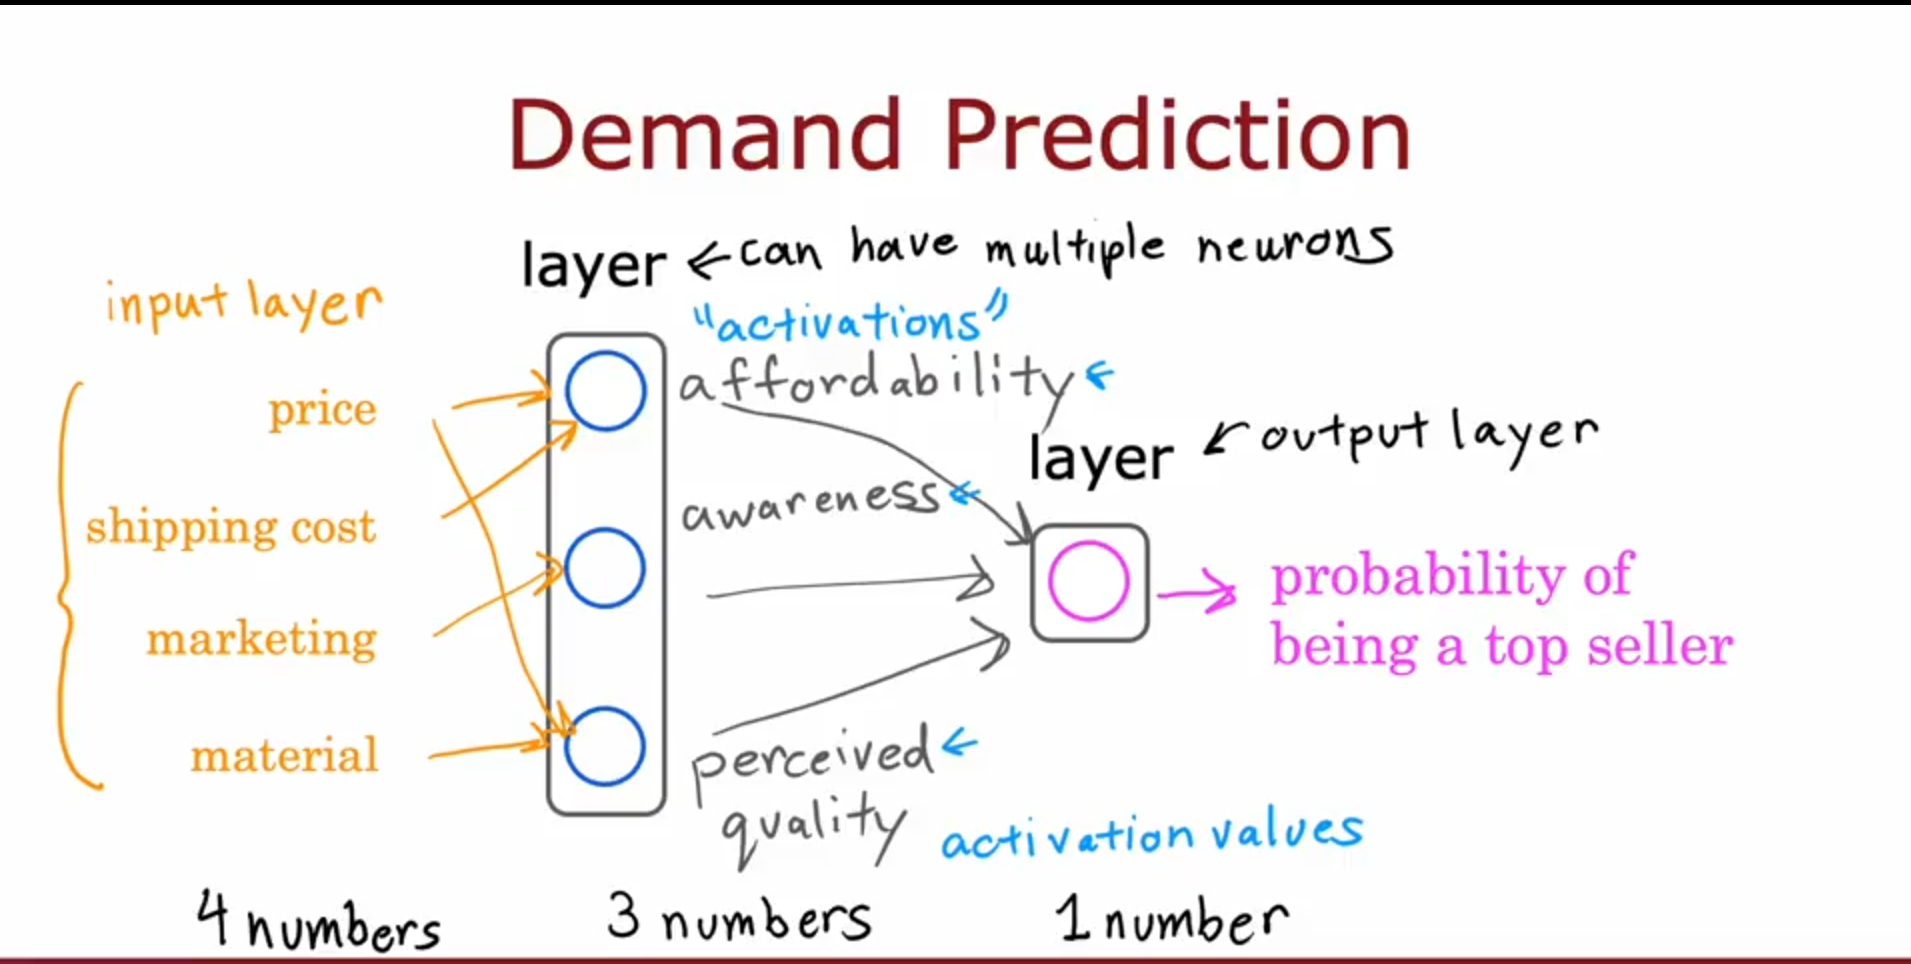

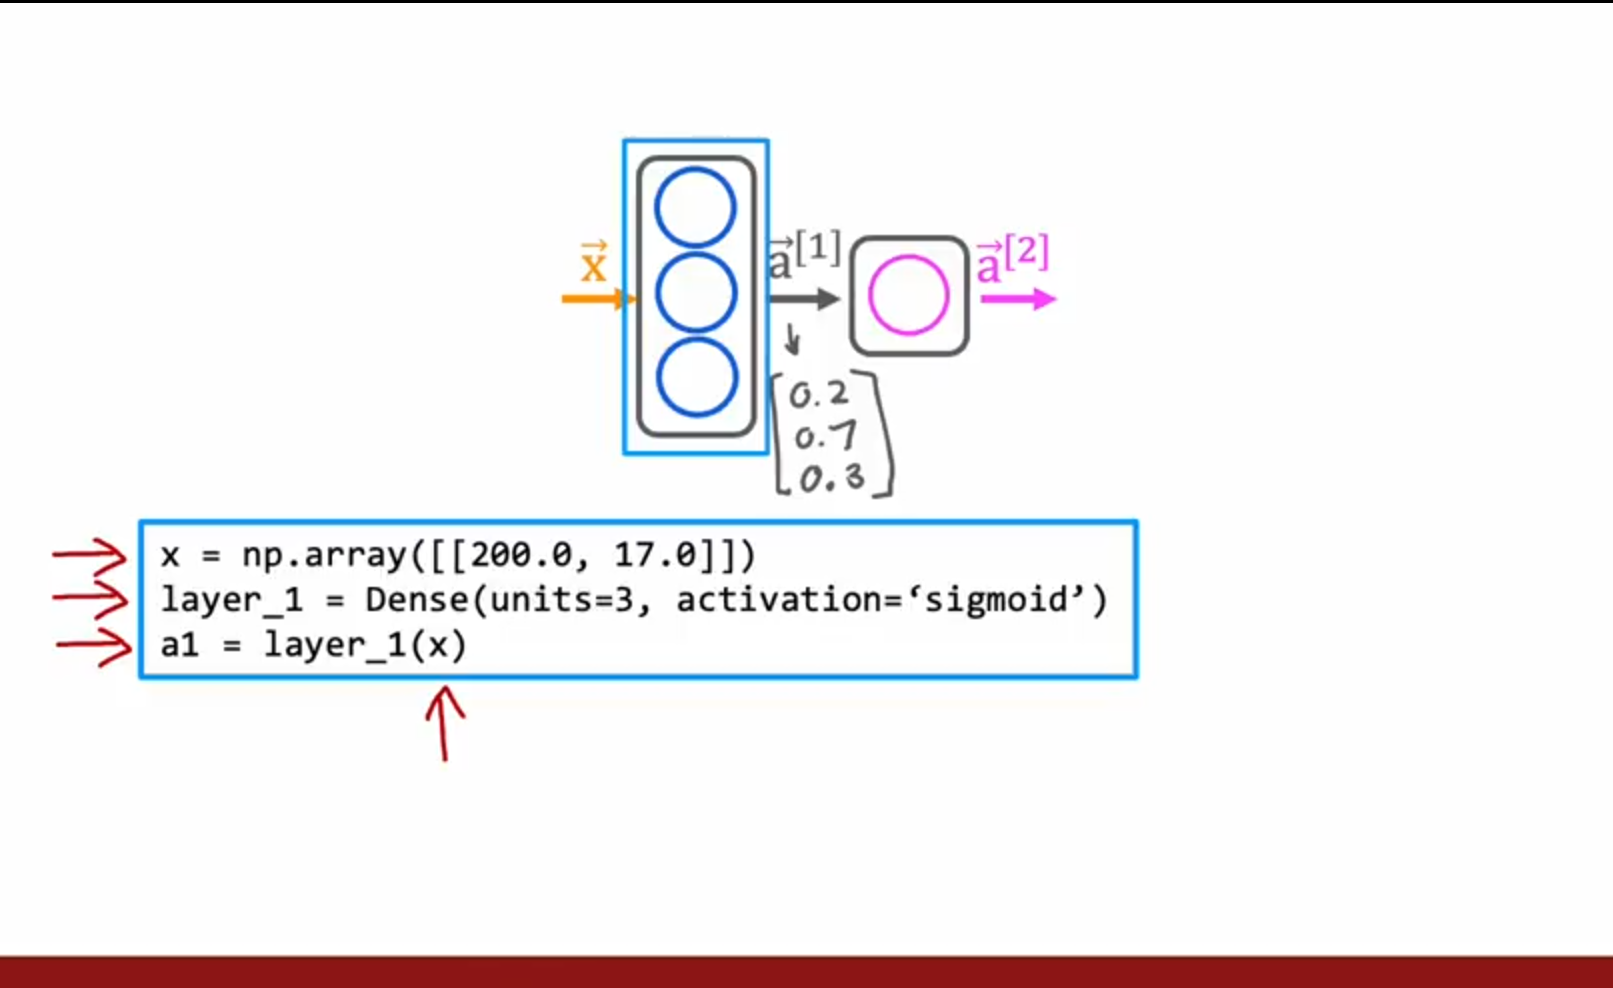

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense

x = tf.constant([[200.0,17.0]],dtype="float32")

layer1 = Dense(units=3,activation="sigmoid")
a1 = layer1(x)

2026-04-27 16:16:03.874387: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-27 16:16:03.923287: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-27 16:16:04.971411: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777295766.053774   16684 gpu_device.cc:2020] Created device /job:localhost/rep

In [2]:
layer2 = Dense(units=1, activation="sigmoid")
a2 = layer2(a1)
tf.print(a2)

[[0.548809]]


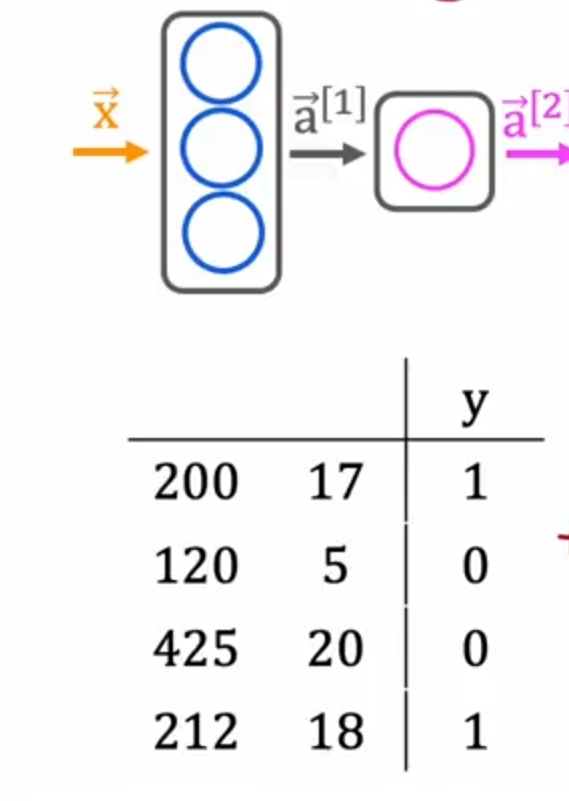

In [3]:
from tensorflow.keras.models import Sequential

In [4]:
#Define the layers
layer_1 = Dense(units=3,activation="sigmoid")
layer_2 = Dense(units=1,activation="sigmoid")

In [5]:
# merge layers and create model
model = Sequential([layer_1,layer_2])


In [6]:
# Data
X = np.array([
    [200.0, 17.0],
    [120.0,  5.0],
    [425.0, 20.0],
    [212.0, 18.0]
])

y = np.array([
    [1], 
    [0], 
    [0], 
    [1]
])

In [7]:
# Create normalization layer
norm_layer = tf.keras.layers.Normalization(axis=1)

#Learn statistics
norm_layer.adapt(X)

# Create normalizated X matrix with laws it learned
X_norm = norm_layer(X)

print(X_norm.numpy())

[[-0.34758085  0.34050262]
 [-1.0560259  -1.7025131 ]
 [ 1.6449208   0.85125655]
 [-0.24131408  0.5107539 ]]


In [8]:
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(), # Log loss (cost function method),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01) # Method that update weights
)

In [11]:
# Training for 100 times and take lessons
model.fit(X,y,epochs=500)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.2578
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.2567
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.2557
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.2546
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.2536
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.2526
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.2516
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.2506
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.2496
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.2486
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.2476
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.2466
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.2456
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.2447
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.2437
Epoch 16/500
1/1 ━━

In [12]:
# PREDICTION

#Create new coffee recipe
new_coffee = np.array([[200.0,17.0]], dtype=np.float32)

#Normalizate the new data
new_coffee_norm = norm_layer(new_coffee)

guess = model.predict(new_coffee_norm)
print(guess)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[0.4158567]]
